## **Business Understanding**

### Real-World Problem
SyriaTel has been losing immense revenue as a result of customer churn. It is in the best interest of any business to retain its existing customers. For this reason, the telecom is incurring marketing costs in a bid to reach new customer base. It is a zero sum game as a significant number of the acquired customers end up churning as well. The task at hand is to determine customers likely to churn by looking out for patterns and come up with measures that would prevent that from happening.

### Stakeholders

1. **Executive Management (CEO, COO, Strategy Team):** This stakeholder group will use this project to quantify expected revenue loss. They will then be able to track churn trends over time by customer segment. That way they can make strategic decisions on whether to invest more in retention programs or acquisition.
2. **Marketing Team:** The marketing team will use this project to target high-risk customers with personalized retention offers. This will reduce spending on mass acquisition campaigns. Additionally, the marketing team can run data-driven retention campaigns instead of blanket promotions.
3. **Customer Service Team:** The project will enable this stakeholder group to flag high-risk customers in the CRM system.This make it possible to prioritize support for customers likely to churn. They will also provide proactive outreach before customers cancel.
4. **Data & Analytics Team:** This group will be interested in monitoring model accuracy, recall, and drift.They might also retrain the model with new data and identify new churn drivers as customer behavior changes.

### Business Questions
1. Which customers are most likely to churn?
2. What factors contribute most to churn?
3. How well can we predict churn compared to random guessing?
4. What actions can SyriaTel take based on these predictions?






In [56]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import plot_tree


In [57]:
#loading the dataset
data =pd.read_csv("data\Telecom.csv")
data.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [58]:
#Summary of dataframe
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [59]:
#Checking for missing values
data.isna().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [60]:
#Checking for duplicate values in the dataframe
data.duplicated().sum()

0

## **Data Understanding**

### Data Source
The data source is Kaggle and is titled *Churn in Telecom's dataset.* The owner of the dataset is David Becks.
It consists of account-level records for SyriaTel subscribers, containing structured features that describe customer service plans, call usage behavior, and support interactions. Each row represents a unique customer account, and the associated features are used as predictors in a supervised learning framework to model and classify customer churn outcomes.

### Suitability of dataset
1. Contains customer-level data relevant to churn behavior
2. Includes usage, service, and support interaction features that influence churn
3. Has a clearly defined churn target variable
4. Suitable for supervised machine learning classification
5. Enables identification of patterns and drivers of customer attrition

### Dataset Overview

- The dataset contains **3,333 customer records** and **21 features (20 predictors + 1 target)**.
- Each record represents a **unique SyriaTel customer account**.
- The features include a mix of **numerical variables** (such as call minutes, call counts, charges, account length, and customer service calls) and **categorical variables** (including state, area code, international plan, and voicemail plan).
- The target variable is **churn**, a binary indicator showing whether a customer discontinued the service.
- Descriptive statistics were generated for all features to understand data distributions, detect potential outliers, and inform preprocessing decisions.

### Feature Selection Justification

The features included in this analysis were selected based on their relevance to customer churn and their suitability for predictive modeling. Usage-related variables such as call minutes, call counts, and associated charges capture customer engagement and consumption patterns, which are strong indicators of satisfaction and likelihood to remain with the service. Service plan attributes, including international and voicemail plans, provide insight into customer needs and pricing sensitivity, both of which influence churn behavior. Customer service interaction features, particularly the number of customer service calls, reflect service quality and customer experience, which are commonly linked to customer attrition. Account-level attributes such as account length represent customer tenure and loyalty. Together, these features are well-defined, largely structured, and measurable prior to churn, making them appropriate predictors for a supervised churn classification model.

### Data Limitations

The dataset is historical and observational, meaning it captures past customer behavior but cannot establish causal relationships between features and churn:
1. The churn variable is imbalanced, with fewer churned customers than non-churned customers, which may bias models toward the majority class if not properly addressed. 
2. Additionally, the data lacks demographic, billing, and customer satisfaction information, which could further improve churn prediction. 
3. Temporal information is limited, preventing analysis of behavior changes over time. 
4. Finally, the dataset represents a snapshot of customer behavior and may not fully reflect future trends or external factors influencing churn.


## **Data Preparation**

Data preparation for this project is essential for three reasons. It ensures data is reproducible, well-documented and justified. Any third party with access to this data can achieve the final analytic dataset by taking the steps included in this repository.
Notably, this dataset is clean as there are no missing values and duplicate records.
### **Dropped Features**
The first feature that will be removed prior to modelling is phone number because it is a unique identifier. It is not a behavioral or service-related feature. State will also be dropped as it is a high cardinality categorical variable. State column will also be developed due to the risk of overfitting.
### **Encoding**
Churn, international plan and voicemail plan will be encoded. Encoding converts categorical labels into a numeric format the model can process. This preserves interpretability and minimizes feature complexity.
### **Feature Scaling**
Feature scaling will be performed because models such as logistic regression are sensitive to the magnitude of input features, and variables measured on different scales can disproportionately influence the model. In the steps below (modeling section), all numerical features were standardized using StandardScaler, which transforms each feature to have a mean of zero and a standard deviation of one. The scaler was fit only on the training data to prevent data leakage, and the same transformation was then applied to the test data. This ensures that all numerical features contribute equally during model training and that model evaluation remains unbiased.


In [61]:
# Dropping unnecessary columns
data = data.drop(columns=["phone number", "state", "area code"])

#Encoding categorical variables
data[["international plan", "voice mail plan"]] = (
    data[["international plan", "voice mail plan"]]
    .replace({"yes": 1, "no": 0})
)

#Encoding target variable
data["churn"] = data["churn"].astype(int)


In [62]:
data.head()

,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


## **Modeling**

In [63]:
X = data.drop(columns="churn")
y = data["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
#The train test is appropropriately split using 25% of the data for testing and 75% for training.
#A random state of 42 is set to ensure reproducibility of results. anyone runnig the code will get the same split.
#Stratify=y ensures that the proportion of classes in the target variable 'churn' is 
# maintained in both the training and testing sets.

In [64]:

# Identify numerical features to be scaled
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns

# Initialize the standard scaler
std_scaler = StandardScaler()

# Create copies of the train and test sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit the scaler on the training data and transform both sets
X_train_scaled[num_features] = std_scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = std_scaler.transform(X_test[num_features])


## **Baseline Model**


In [65]:
# Initialize a naive baseline classifier
baseline_dummy = DummyClassifier(strategy="most_frequent", random_state=42)

# Train the baseline model
baseline_dummy.fit(X_train, y_train)

# Generate predictions on the test set
baseline_predictions = baseline_dummy.predict(X_test)

# Compute recall for the churn class (1)
baseline_recall = recall_score(y_test, baseline_predictions)

baseline_recall


0.0

### **Why use a simple Dummy Classifier**
A simple DummyClassifier was used to always predict the most common outcome in the data. This gives a basic reference point for performance, showing how well a model would do without learning any patterns. Using this baseline helps confirm that any later machine learning model actually performs better than a naïve approach, especially in identifying customers who are likely to churn.


## **Logistic Regression**

In [66]:
# Initialize logistic regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Fit the model on scaled training data
lr_model.fit(X_train_scaled, y_train)

# Make predictions on scaled test data
lr_predictions = lr_model.predict(X_test_scaled)

# Compute recall for the churn class
lr_recall_score = recall_score(y_test, lr_predictions)

lr_recall_score


0.24793388429752067

In [67]:
print(classification_report(y_test, lr_predictions))


              precision    recall  f1-score   support

           0       0.88      0.96      0.92       713
           1       0.55      0.25      0.34       121

    accuracy                           0.86       834
   macro avg       0.71      0.61      0.63       834
weighted avg       0.83      0.86      0.84       834



## **Explanation**
A recall of 0.248 means the logistic regression model correctly identifies about **25% of customers who actually churned**. Compared to the baseline DummyClassifier (which typically predicts no churn and has very low or zero recall for churners), this represents a clear improvement, showing that the model is learning meaningful patterns related to churn rather than guessing the majority class.

The next step is to proceed to a confusion matrix.
It provides a breakdown of prediction outcomes, showing true positives, false positives, true negatives, and false negatives. For a churn problem, this helps assess how many churners are correctly identified versus missed, which is critical since false negatives (missed churners) have direct business cost. The confusion matrix complements recall by making model errors more interpretable and linking model performance to real-world retention decisions.


### **Confusion Matrix**

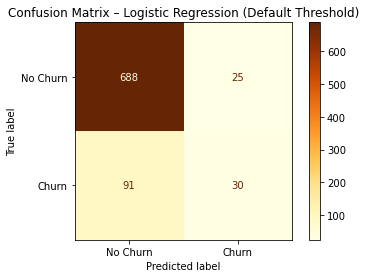

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       713
           1       0.55      0.25      0.34       121

    accuracy                           0.86       834
   macro avg       0.71      0.61      0.63       834
weighted avg       0.83      0.86      0.84       834



In [68]:
# Generate confusion matrix
lr_cm = confusion_matrix(y_test, lr_predictions)

# Display confusion matrix
lr_disp = ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["No Churn", "Churn"]
)
lr_disp.plot(cmap="YlOrBr")
plt.title("Confusion Matrix – Logistic Regression (Default Threshold)")
plt.show()

# Print classification report
print(classification_report(y_test, lr_predictions))


## **Explanation**
While the logistic regression model significantly improves upon the baseline by identifying some churners, it still prioritizes non-churn predictions, resulting in a relatively low churn recall. This indicates that further optimization is needed to reduce false negatives, which are costly from a business perspective.

This creates the need to lower the decision threshold to 0.3 which is not very aggressive (moderate).

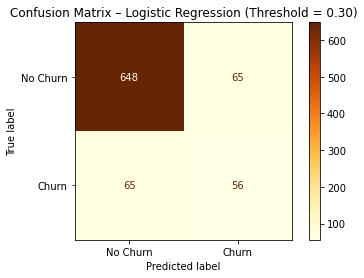

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       713
           1       0.46      0.46      0.46       121

    accuracy                           0.84       834
   macro avg       0.69      0.69      0.69       834
weighted avg       0.84      0.84      0.84       834



In [69]:
# Generate predicted probabilities for the churn class (class = 1)
churn_probabilities = lr_model.predict_proba(X_test_scaled)[:, 1]

# Define a lower decision threshold to increase churn recall
custom_threshold = 0.30

# Convert probabilities to class predictions based on the chosen threshold
churn_predictions_30 = (churn_probabilities >= custom_threshold).astype(int)

# Create the confusion matrix
cm_threshold_30 = confusion_matrix(y_test, churn_predictions_30)

# Display the confusion matrix
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm_threshold_30,
    display_labels=["No Churn", "Churn"]
)
cm_display.plot(cmap="YlOrBr")
plt.title("Confusion Matrix – Logistic Regression (Threshold = 0.30)")
plt.show()

# Print classification metrics
print(classification_report(y_test, churn_predictions_30))


### **Explanation**
Lowering the decision threshold from the default 0.50 to 0.30 changes how the logistic regression model classifies churn risk. Compared to the default confusion matrix, the model now identifies a substantially larger number of actual churners, as shown by the increase in recall for the churn class from approximately 0.25 to 0.46. This indicates that nearly half of the customers who eventually churn are now correctly flagged by the model, reducing the number of false negatives, which are particularly costly in a churn prevention context.

However, this improvement in recall comes with a trade-off. The model now predicts churn for more customers overall, which leads to an increase in false positives and a slight reduction in overall accuracy. Despite this, the adjusted threshold better aligns with the business objective of proactive retention, where it is preferable to contact some customers who may not churn rather than fail to identify customers who are at high risk of leaving.

At this point, all roads lead to a decision tree. A decision tree helps capture non-linear churn behavior, improves interpretability, and provides a strong alternative baseline to compare against logistic regression.


## **Decision Tree**

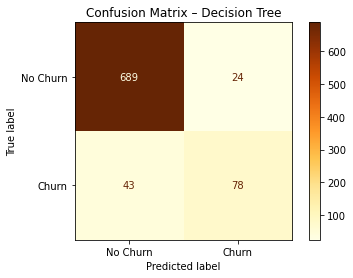

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       713
           1       0.76      0.64      0.70       121

    accuracy                           0.92       834
   macro avg       0.85      0.81      0.83       834
weighted avg       0.92      0.92      0.92       834



In [70]:
# Initialize a decision tree classifier with constraints to reduce overfitting
# Limiting depth and minimum samples helps the model generalize better
churn_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)

# Train the decision tree on the training data
churn_tree.fit(X_train, y_train)

# Generate predictions on the test set
tree_predictions = churn_tree.predict(X_test)

# Compute the confusion matrix
tree_cm = confusion_matrix(y_test, tree_predictions)

# Visualize the confusion matrix
tree_disp = ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=["No Churn", "Churn"]
)
tree_disp.plot(cmap="YlOrBr")
plt.title("Confusion Matrix – Decision Tree")
plt.show()

# Display classification metrics
print(classification_report(y_test, tree_predictions))


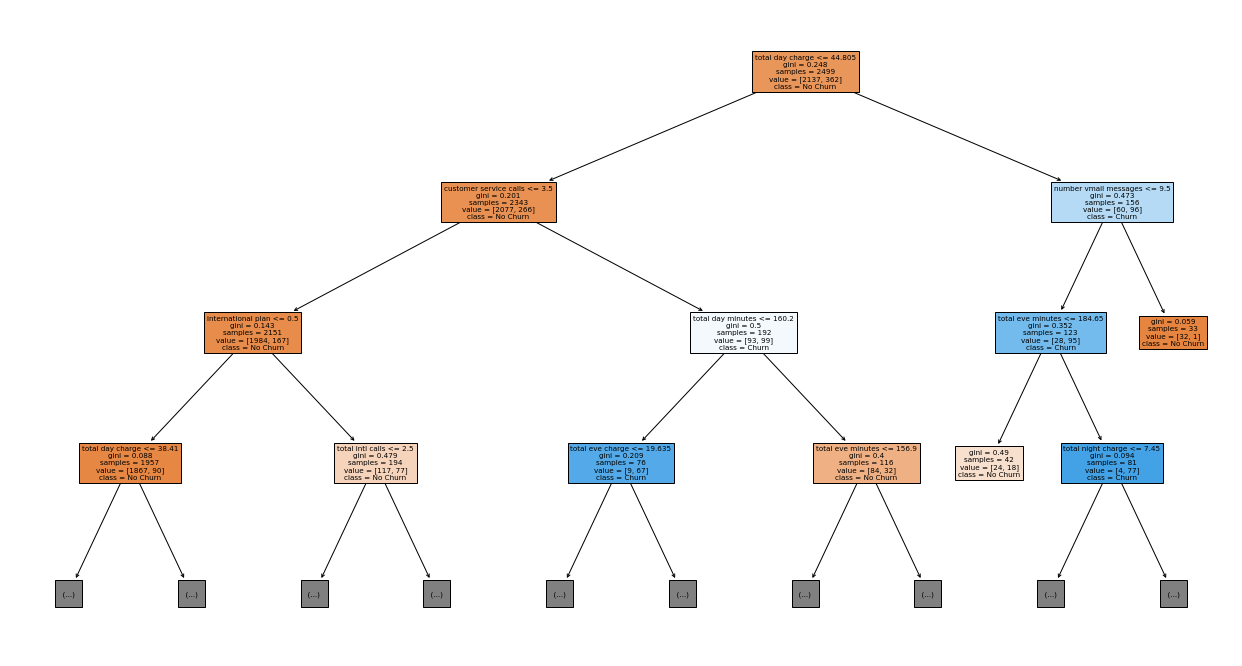

In [71]:
# Set a larger figure size for better readability
plt.figure(figsize=(22, 12))

# Visualize the top levels of the trained decision tree
plot_tree(
    churn_tree,
    feature_names=X_train.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    max_depth=3
)

plt.show()


## **Explanation**
The decision tree substantially outperforms logistic regression across all key metrics. It identifies nearly two-thirds of churners, while also maintaining higher precision and overall accuracy. This indicates the tree is capturing non-linear decision rules and feature interactions that logistic regression cannot model effectively.

Because it identifies more customers who are likely to churn, misses fewer at-risk customers, and is easy to explain, the decision tree was chosen as the final model for assessing churn risk at SyriaTel.


## **Evaluation**

## 1. Which customers are most likely to churn?

Customers most likely to churn are those who exhibit **high service friction and low engagement patterns**. Specifically, the decision tree identifies customers with **frequent customer service calls**, **international plans**, and **unfavorable usage patterns** (such as low day-time usage combined with higher charges) as having the highest churn risk. Shorter account tenure also increases churn likelihood, indicating that newer customers are more vulnerable to leaving before becoming fully retained.

---

## 2. What factors contribute most to churn?

The decision tree highlights **customer service calls** as the strongest driver of churn, suggesting that unresolved issues or dissatisfaction strongly influence customer exit. Other major contributors include **international plan subscription**, **total day minutes**, and **account length**. These factors indicate that churn is primarily driven by a combination of **service experience**, **pricing sensitivity**, and **customer engagement**, rather than demographic or geographic attributes.

---

## 3. How well can we predict churn compared to random guessing?

Compared to random or naïve guessing, the decision tree performs **significantly better**. While a baseline model predicting the majority class fails to meaningfully identify churners, the decision tree correctly identifies approximately **64% of customers who actually churn**, with high overall accuracy. This demonstrates that the model is learning real behavioral patterns and provides reliable predictive value beyond chance.

---

## 4. What actions can SyriaTel take based on these predictions?

SyriaTel can use the model to **proactively identify high-risk customers** and intervene before churn occurs. Recommended actions include prioritizing high-risk customers for **retention offers**, improving **customer support response for frequent callers**, and reviewing pricing or service quality for customers on international plans. By shifting focus from broad customer acquisition to **targeted retention strategies**, SyriaTel can reduce churn, protect revenue, and improve customer lifetime value.


## **Recommendations**

* Focus on **retaining high-risk customers** instead of broad customer acquisition.
* Prioritize **frequent customer service callers** for faster resolution and proactive outreach.
* Review **international plan pricing and billing clarity** to reduce cost-driven churn.
* Introduce **early engagement programs** for new customers with short account tenure.
* Integrate churn predictions into **marketing and customer service workflows**.



## **Conclusion**

* SyriaTel’s churn problem can be effectively addressed using **predictive analytics**.
* The decision tree model accurately identifies customers at risk of churn.
* Targeted retention strategies are **more cost-effective** than continuous customer replacement.
* Ongoing model monitoring will ensure sustained impact over time.